In [32]:

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt


In [33]:

env = gym.make ( "FrozenLake-v1", map_name = "4x4", is_slippery = True )

n_states = env.observation_space.n
n_actions = env.action_space.n

print ( "States:", n_states )
print ( "Actions:", n_actions )


States: 16
Actions: 4


In [34]:

alpha = 0.1
gamma = 0.99

epsilon_start = 1.0
epsilon_end = 0.01
episodes = 5000

epsilon_decay = ( epsilon_start - epsilon_end ) / episodes

Q = np.zeros ( ( n_states, n_actions ) )

print ( "Q-table shape:", Q.shape )


Q-table shape: (16, 4)


In [35]:

# Goal - 1 or hole - 0

rewards_per_episode = []
ep = []
epsilon = epsilon_start

for episode in range(episodes):
    
    state, _ = env.reset()
    done = False
    total_reward = 0
    
    while not done:

        # Exploration vs Exploitation
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])
        
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Q learning
        Q[state, action] = Q[state, action] + alpha * ( reward + gamma * np.max(Q[next_state]) - Q[state, action] )
        
        state = next_state
        total_reward += reward
    
    rewards_per_episode.append ( total_reward )
    ep.append ( episode )

    # The decay!
    epsilon = max(epsilon_end, epsilon - epsilon_decay)

print ( "Training complete" )
print ( len ( rewards_per_episode ), len ( ep ) )

Training complete
5000 5000


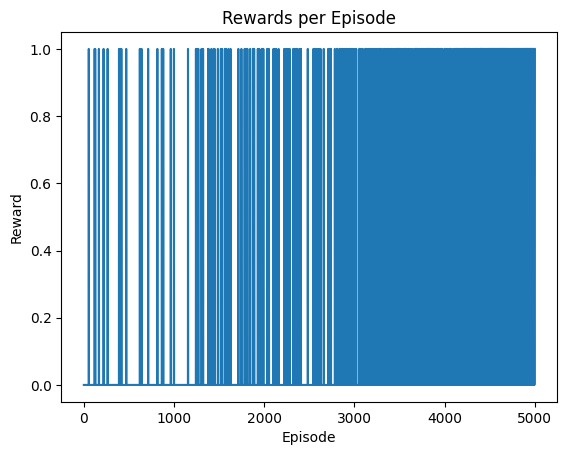

In [36]:
plt.plot(rewards_per_episode)
plt.title("Rewards per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()


In [37]:

test_episodes = 1000
success = 0

for _ in range(test_episodes):
    state, _ = env.reset()
    done = False
    
    while not done:
        action = np.argmax(Q[state])
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        if reward == 1:
            success += 1

print(f"Success rate over {test_episodes} episodes: {success/test_episodes}")


Success rate over 1000 episodes: 0.756


In [30]:
# Left, Down, Right, Up
print(Q)


[[0.54785822 0.51208076 0.50785414 0.50956141]
 [0.34779927 0.41824403 0.30113046 0.48671738]
 [0.45251345 0.45068931 0.43396426 0.46870135]
 [0.23739816 0.32588811 0.33826808 0.45383542]
 [0.56128086 0.41737305 0.40348476 0.3623453 ]
 [0.         0.         0.         0.        ]
 [0.32066114 0.19460586 0.18721818 0.17784155]
 [0.         0.         0.         0.        ]
 [0.36294338 0.35640875 0.53363451 0.58591459]
 [0.49574674 0.6091548  0.57696126 0.49801702]
 [0.6334026  0.43685471 0.358098   0.34298949]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.22154083 0.50749298 0.70456755 0.53706167]
 [0.76612303 0.85833292 0.7819066  0.77390092]
 [0.         0.         0.         0.        ]]
